In [1]:
import tensorflow as tf
import pathlib

# 1. Paths & basic config
DATA_DIR = r"C:\Users\User\Downloads\eyedataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

data_dir = pathlib.Path(DATA_DIR)

In [2]:
# 2. Creating train / val datasets from a single folder
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 4217 files belonging to 4 classes.
Using 3374 files for training.
Found 4217 files belonging to 4 classes.
Using 843 files for validation.
Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


In [3]:
# 3. Performance tweaks
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [4]:
# 4. Data augmentation + rescaling
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.1),
    ]
)

preprocess_input = tf.keras.layers.Rescaling(1.0 / 255)

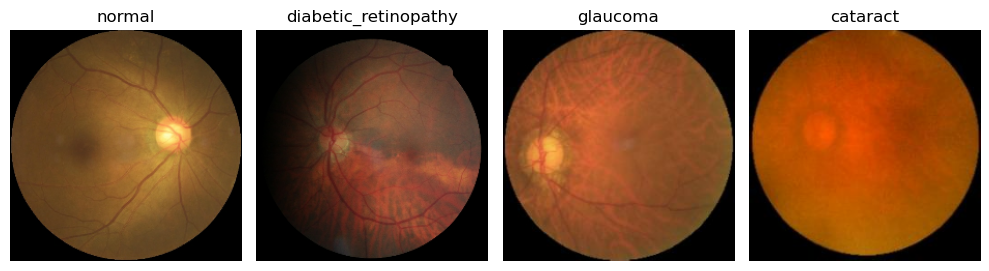

In [5]:
import matplotlib.pyplot as plt

# Load one full batch
images, labels = next(iter(train_ds))

# Track first example per class
seen = {}
plt.figure(figsize=(10, 6))

for i in range(len(images)):
    label = int(labels[i].numpy())
    class_name = class_names[label]

    if class_name not in seen:
        seen[class_name] = images[i]

    if len(seen) == len(class_names):
        break

# Plot
for idx, (cls, img) in enumerate(seen.items()):
    plt.subplot(1, len(class_names), idx+1)
    plt.imshow(img.numpy().astype("uint8"))
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [6]:
# 5. Base model (transfer learning)
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

IMG_SIZE = (224, 224)

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)
base_model.trainable = False

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.1),
    ]
)

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
# use real preprocess_input instead of simple Rescaling
x = tf.keras.layers.Lambda(preprocess_input)(x)

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
# 6. Build the model
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           5,124 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [9]:
# 7. Train head
callback_es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[callback_es]
)

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 67s 606ms/step - accuracy: 0.7992 - loss: 0.5235 - val_accuracy: 0.8007 - val_loss: 0.5513
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 68s 612ms/step - accuracy: 0.8206 - loss: 0.4681 - val_accuracy: 0.8126 - val_loss: 0.5503
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 72s 611ms/step - accuracy: 0.8311 - loss: 0.4429 - val_accuracy: 0.8090 - val_loss: 0.5431
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 72s 652ms/step - accuracy: 0.8404 - loss: 0.4314 - val_accuracy: 0.8126 - val_loss: 0.5279
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 73s 653ms/step - accuracy: 0.8477 - loss: 0.4000 - val_accuracy: 0.8090 - val_loss: 0.5522
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 70s 632ms/step - accuracy: 0.8437 - loss: 0.4028 - val_accuracy: 0.8149 - val_loss: 0.5421
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 70s 625ms/step - accuracy: 0.8356 - loss: 0.4166 - val_accuracy: 0.8209 - val_loss: 0.5297
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 70s 637ms/step - accuracy: 0.8464 - loss: 0

In [10]:
for images, labels in train_ds.take(1):
    print("Labels in batch:", labels.numpy()[:20])
    print("Class names:", class_names)

Labels in batch: [1 0 2 2 1 3 2 0 1 1 3 1 0 3 2 2 3 2 1 0]
Class names: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


In [11]:
base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.7)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[callback_es]
)

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 113s 895ms/step - accuracy: 0.7474 - loss: 0.6364 - val_accuracy: 0.8695 - val_loss: 0.3876
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 96s 873ms/step - accuracy: 0.8893 - loss: 0.2907 - val_accuracy: 0.8956 - val_loss: 0.2982
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 96s 870ms/step - accuracy: 0.8961 - loss: 0.2556 - val_accuracy: 0.9027 - val_loss: 0.2907
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 97s 889ms/step - accuracy: 0.9147 - loss: 0.2122 - val_accuracy: 0.9288 - val_loss: 0.2489
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 98s 900ms/step - accuracy: 0.9334 - loss: 0.1876 - val_accuracy: 0.9205 - val_loss: 0.2544
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 100s 910ms/step - accuracy: 0.9430 - loss: 0.1530 - val_accuracy: 0.9265 - val_loss: 0.2430
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 98s 895ms/step - accuracy: 0.9477 - loss: 0.1405 - val_accuracy: 0.9229 - val_loss: 0.2794
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 98s 893ms/step - accuracy: 0.9659 - loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


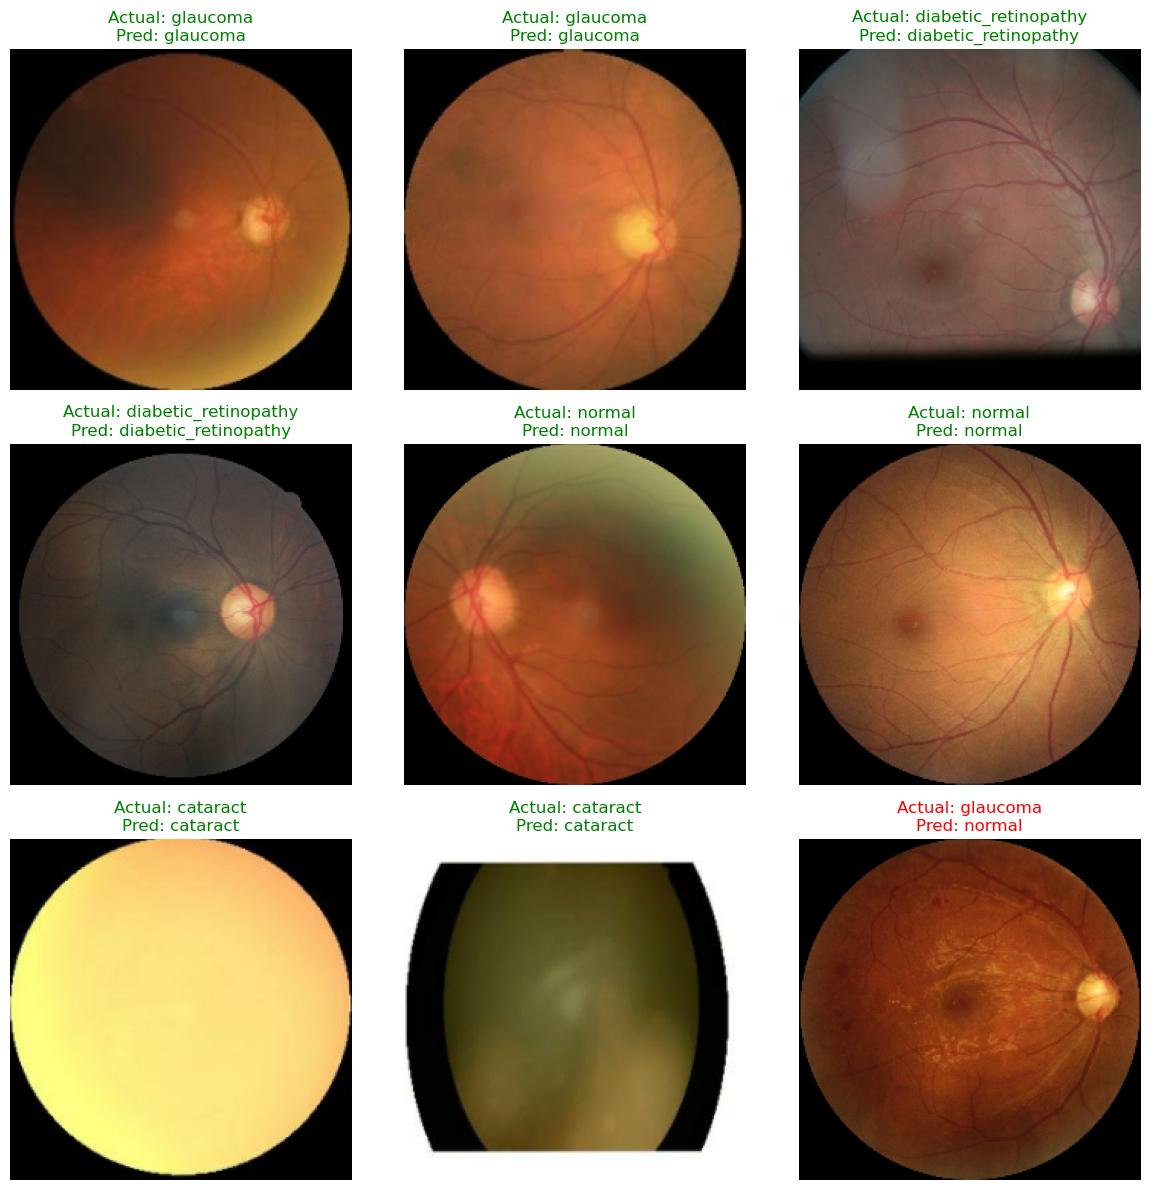

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch from validation set
images, labels = next(iter(val_ds))

# Predict
preds = model.predict(images)
pred_classes = np.argmax(preds, axis=1)

plt.figure(figsize=(12, 12))

num_to_show = 9  # show 9 images
for i in range(num_to_show):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    actual = class_names[int(labels[i])]
    predicted = class_names[pred_classes[i]]
    color = "green" if actual == predicted else "red"
    plt.title(f"Actual: {actual}\nPred: {predicted}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()


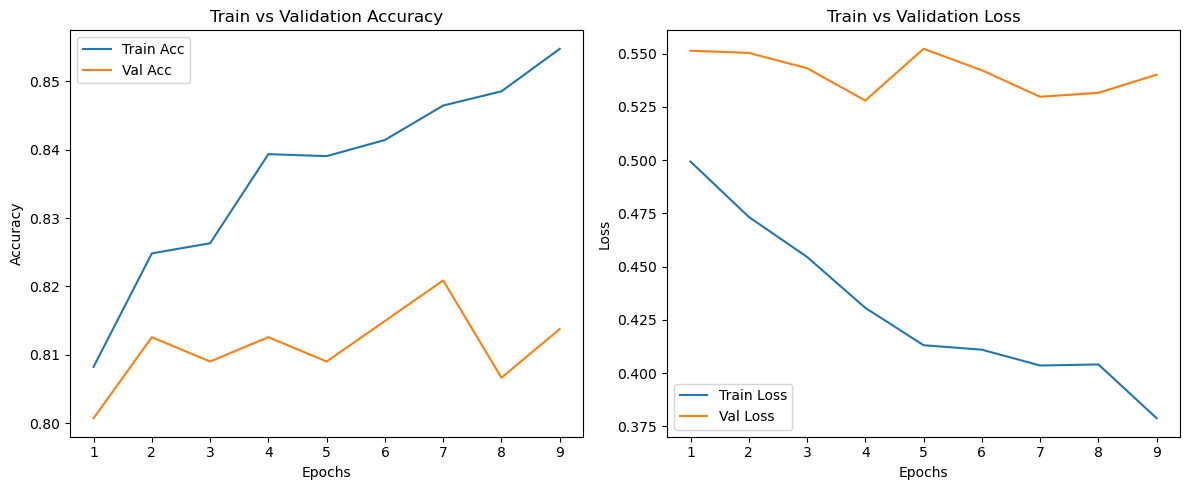

In [13]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs, acc, label="Train Acc")
plt.plot(epochs, val_acc, label="Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [14]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

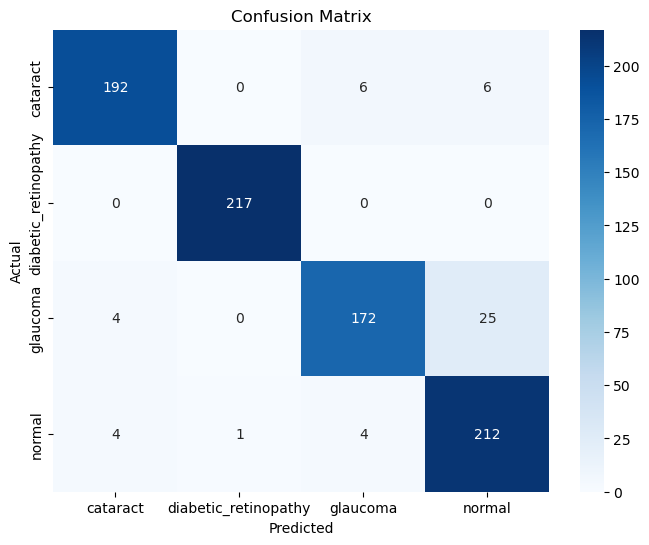

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [16]:
import numpy as np

y_true = []
y_score = []

for images, labels in val_ds:
    probs = model.predict(images)          # shape: (batch, n_classes)
    y_true.extend(labels.numpy())
    y_score.append(probs)

y_true = np.array(y_true)
y_score = np.vstack(y_score)               # shape: (N, n_classes)
n_classes = len(class_names)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 500ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [17]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# one-vs-rest binarization
y_true_bin = label_binarize(y_true, classes=range(n_classes))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# optional micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


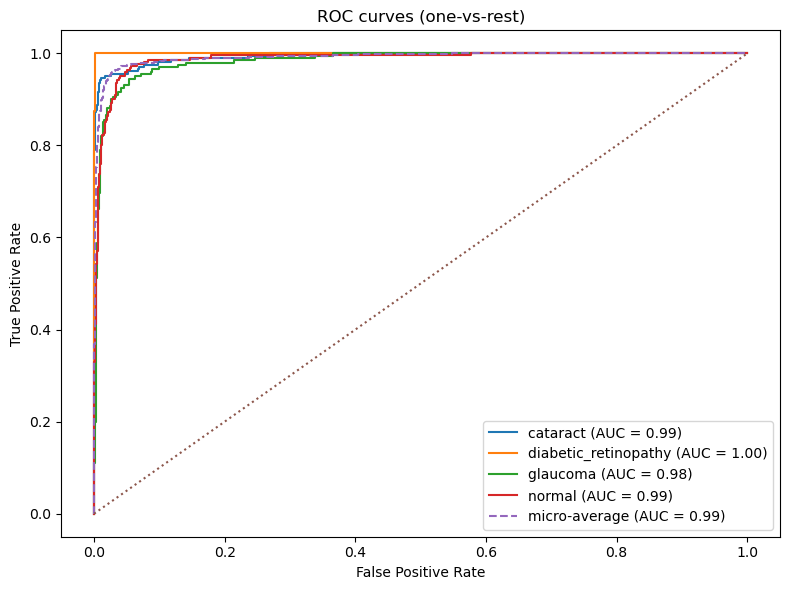

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# per-class curves
for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})"
    )

# micro-average curve
plt.plot(
    fpr["micro"],
    tpr["micro"],
    linestyle="--",
    label=f"micro-average (AUC = {roc_auc['micro']:.2f})"
)

# random baseline
plt.plot([0, 1], [0, 1], linestyle=":")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves (one-vs-rest)")
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    probs = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(probs, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [22]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd

prec, rec, f1, support = precision_recall_fscore_support(
    y_true, 
    y_pred, 
    labels=range(len(class_names)),
    average=None
)

overall_accuracy = accuracy_score(y_true, y_pred)

metrics_table = pd.DataFrame({
    "Class": class_names,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Support": support
})

print("Overall Accuracy:", overall_accuracy)
print(metrics_table)


Overall Accuracy: 0.9406880189798339
                  Class  Precision    Recall  F1 Score  Support
0              cataract   0.960000  0.941176  0.950495      204
1  diabetic_retinopathy   0.995413  1.000000  0.997701      217
2              glaucoma   0.945055  0.855721  0.898172      201
3                normal   0.872428  0.959276  0.913793      221


In [23]:
model.save("eye_disease_classifier.h5")
print("Model saved as eye_disease_classifier.h5")

Model saved as eye_disease_classifier.h5


In [24]:
model.save(r"C:\Users\User\Downloads\eyedataset\eye_model.h5")